In [44]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso, ElasticNet

In [26]:
estudiantes= pd.read_csv ('../limpios/estudiantes_regresion.csv', index_col=0)
estudiantes.head(5)

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado,tiene_tutor_No,tiene_tutor_Sí
0,-0.229884,-1.434220,0.695453,-0.249372,0.422422,-0.420062,0.533171,1.095502,84.4,0.337025,-1.217123,1.217123
1,0.200041,0.745231,0.520023,-1.795930,-1.591853,-1.728668,0.533171,-2.491313,72.0,0.337025,0.821609,-0.821609
2,-1.146769,1.396304,0.034724,0.561561,0.422422,-0.420062,0.311118,1.095502,80.0,0.337025,0.821609,-0.821609
3,-0.706248,0.816929,0.487042,1.190730,-0.153085,-0.420062,1.843873,-0.879564,78.2,0.337025,0.821609,-0.821609
4,-1.870671,-0.247356,-1.069572,-0.252267,-0.728592,0.888543,1.843873,0.352495,66.0,0.337025,0.821609,-0.821609


## Separacion en parte de entreno y de test

In [27]:
tv='nota_final'

X= estudiantes.drop(columns=[tv])
y= estudiantes[tv]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del consujo del entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de test: {X_test.shape}")

Tamaño del consujo del entrenamiento: (800, 11)
Tamaño del conjunto de test: (200, 11)


In [29]:
modelo= LinearRegression()

In [30]:
modelo.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
y_pred= modelo.predict(X_test)

# Validacion

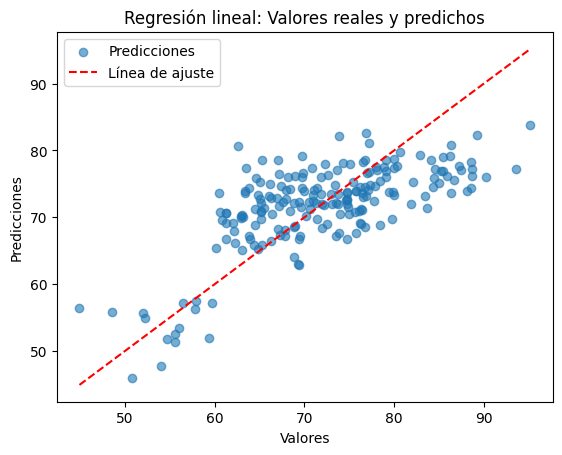

In [32]:
# Miramos con scatterplot
plt.scatter(y_test, y_pred, label='Predicciones', alpha= 0.6)

#Lineas de referencia

valor_min=min(y_test.min(), y_pred.min())
valor_max=max(y_test.max(),y_pred.max())
plt.plot([valor_min, valor_max], [valor_min, valor_max], color="red", linestyle="--", label="Línea de ajuste")

plt.xlabel("Valores")
plt.ylabel("Predicciones")
plt.title("Regresión lineal: Valores reales y predichos")
plt.legend()
plt.show()

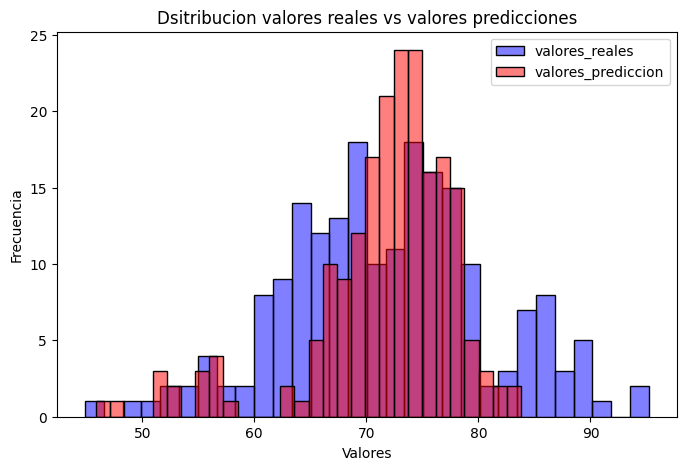

In [33]:
### Comparativa de distribuciones

plt.figure(figsize=(8,5))
n_bins=30

sns.histplot(y_test, bins= n_bins, edgecolor='black', color='blue', alpha= 0.5, label='valores_reales')
sns.histplot(y_pred, bins=n_bins, edgecolor='black', color='red', alpha=0.5, label='valores_prediccion')

plt.xlabel('Valores')
plt.ylabel('Frecuencia')
plt.title('Dsitribucion valores reales vs valores predicciones')
plt.legend()
plt.show()

## Residuos

In [34]:
residuos= y_test - y_pred

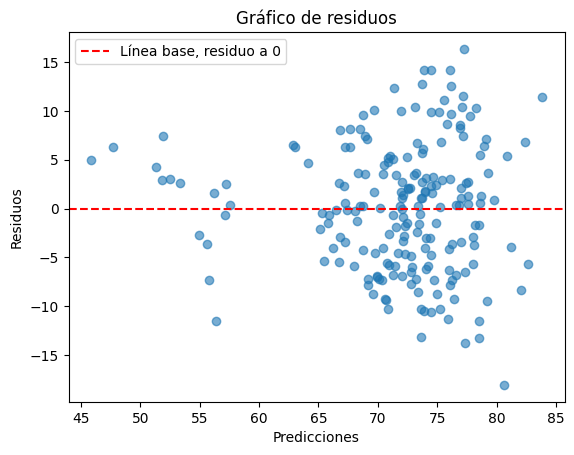

In [35]:
#Gráfico scatterplot

plt.scatter(y_pred, residuos, alpha= 0.6)
plt.axhline( y=0, color='red', linestyle='--', label='Línea base, residuo a 0')

plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Gráfico de residuos')
plt.legend()
plt.show()

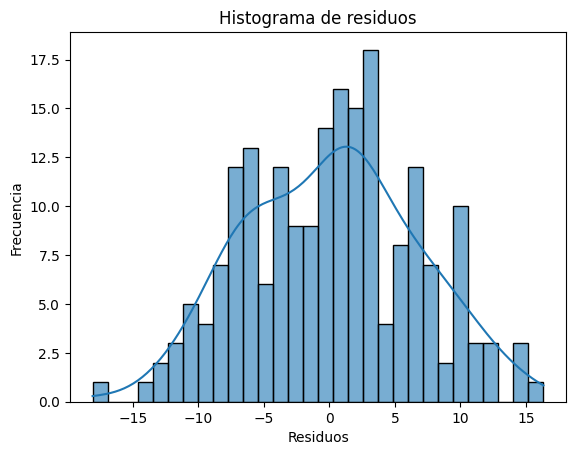

In [ ]:
#Histograma

sns.histplot(residuos, bins=30, kde=True, edgecolor='black',alpha=0.6)

plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Histograma de residuos')
plt.show()

## Análisis de características

In [37]:
coef_estudiantes= pd.DataFrame({'Feature': X.columns.to_list(), 'Coefficient': modelo.coef_})

In [38]:
coef_estudiantes.sort_values(by='Coefficient',ascending=False, key=abs)

,Feature,Coefficient
8,aprobado,3.980254
0,horas_estudio_semanal,2.541608
1,nota_anterior,1.821717
2,tasa_asistencia,1.223426
7,estilo_aprendizaje,0.425017
10,tiene_tutor_Sí,0.225613
9,tiene_tutor_No,-0.225613
3,horas_sueno,-0.196911
4,edad,0.188922
5,nivel_dificultad,0.095994


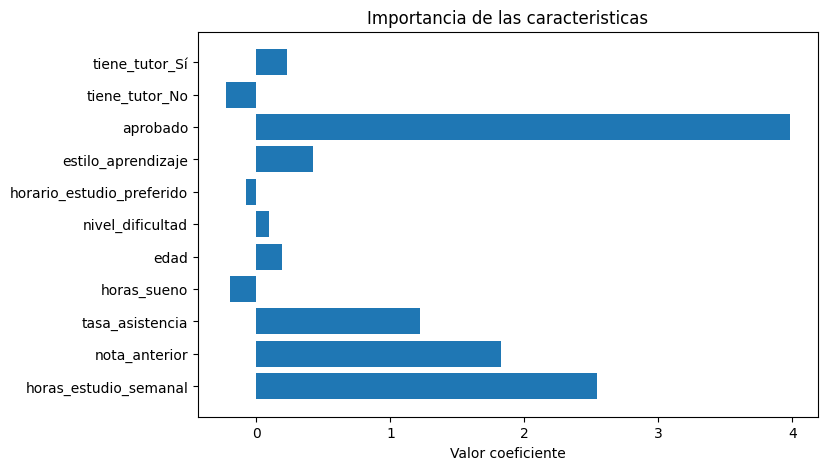

In [39]:
#Visualizarlos en gráfico

plt.figure(figsize=(8,5))
plt.barh(coef_estudiantes['Feature'], coef_estudiantes['Coefficient'])
plt.xlabel('Valor coeficiente')
plt.title('Importancia de las caracteristicas')
plt.show()

## Métricas

In [40]:
#Predicciones

y_train_pred= modelo.predict(X_train)
y_test_pred=modelo.predict(X_test)

In [41]:
#Evaluamos el modelo
metricas= {
    'train': {
        'R2': r2_score(y_train, y_train_pred),
        'MAE': mean_absolute_error(y_train, y_train_pred),
        'RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        },

    'test': {
        'R2': r2_score(y_test, y_test_pred),
        'MAE': mean_absolute_error(y_test, y_test_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test,y_test_pred)),
    },
    }

estudiantes_metricas=pd.DataFrame(metricas).T

In [42]:
estudiantes_metricas.round(2)

# No explica muy bien los datos, R2 no cercano al 1. 

,R2,MAE,RMSE
train,0.53,5.29,6.62
test,0.48,5.31,6.51


Para intentar mejorar el sistema de correlaciones, nos quedamos solo con las variables que mayor coeficiente de importancia tienen para el modelo, eliminando el resto y aprobado, al estar relacionada directamente con la nota. Para ello:  
- Calculamos las metricas de un modelo reducido en el notebook 'regresion_optimización_modelo', donde nos quedamos solo con las variables que mayor coeficiente de importancia tienen para el modelo. Realizando este análisis de evaluación, el resultado R2 es incluso más bajo en R2 teniendo en cuenta solo las variables con más importancia para el modelo.

Por tanto, al ser más alto el de este notebook, es el que se va a usar finalmente para el modelo

## Entrenamiento final

In [43]:
import joblib

# Entrenar el modelo con todo el conjunto de datos
model_final = LinearRegression()
model_final.fit(X, y)

# Guardar el modelo entrenado para producción
joblib.dump(model_final, "modelo_regresion.pkl")

['modelo_regresion.pkl']

Regularizamos

In [49]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
}

metrics_results = {}

#Para usarlo en todos los modelos:
for name, model in models.items():
    model.fit(X_train, y_train) 

    # Predecir en entrenamiento y prueba
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculamos las distintas métricas
    metrics_results[name] = {
        "Train R²": r2_score(y_train, y_train_pred),
        "Train MAE": mean_absolute_error(y_train, y_train_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Test R²": r2_score(y_test, y_test_pred),
        "Test MAE": mean_absolute_error(y_test, y_test_pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
    }

# se crea el dataframe
estudiantes_metricas = pd.DataFrame(metrics_results).T

In [50]:
estudiantes_metricas.round(2)

,Train R²,Train MAE,Train RMSE,Test R²,Test MAE,Test RMSE
Linear,0.53,5.29,6.62,0.48,5.31,6.51
Ridge,0.53,5.29,6.62,0.48,5.31,6.51
Lasso,0.53,5.28,6.63,0.49,5.30,6.49
ElasticNet,0.53,5.29,6.63,0.49,5.29,6.49
